# Check RMSE and ACC for Factual Simulations
Determine if 10 ensemble members is sufficient

Import statments

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd

In [3]:
# Configuration
start, stop, nens = 2004, 2023, 20
years    = np.arange(start, stop + 1)
ens_list = np.arange(1, nens + 1)
files = [
    [f"/glade/work/smhenry/NeuralGCM/data/tracks/factual/ens{ens}_{year}_JASO_TC_tracks_factual.txt"
     for ens in range(1, nens + 1)]
    for year in range(start, stop + 1)
]

# Count functions
def count_NA(file):
    count, in_TC, is_in_NA = 0, False, False
    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                if is_in_NA: count += 1
                is_in_NA, in_TC = False, True
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon, lat = float(data[2]), float(data[3])
                    if ((285 <= lon <= 360 and 0 <= lat <= 50)
                            or (276 <= lon < 285 and 10 <= lat <= 50)
                            or (262 <= lon < 276 and 16.5 <= lat <= 50)):
                        is_in_NA = True
    if is_in_NA: count += 1
    return count

def count_NWP(file):
    count, in_TC, is_in_NWP = 0, False, False
    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                if is_in_NWP: count += 1
                is_in_NWP, in_TC = False, True
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon, lat = float(data[2]), float(data[3])
                    if 100 <= lon <= 180 and 0 <= lat <= 50:
                        is_in_NWP = True
    if is_in_NWP: count += 1
    return count

def count_NEP(file):
    count, in_TC, is_in_NEP = 0, False, False
    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                if is_in_NEP: count += 1
                is_in_NEP, in_TC = False, True
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon, lat = float(data[2]), float(data[3])
                    if ((275 <= lon <= 284 and 0 <= lat <= 10)
                            or (260 <= lon < 275 and 0 <= lat <= 16.5)
                            or (180 <= lon < 260 and 0 <= lat <= 50)):
                        is_in_NEP = True
    if is_in_NEP: count += 1
    return count

def count_TCs_ibtracs(year, basin, storm_type):
    df = pd.read_csv(f"/glade/work/smhenry/NeuralGCM/data/ibtracs/IBTrACS_{year}_JASO.csv")
    df["time"] = pd.to_datetime(df["time"])
    durations = df.groupby("stormid")["time"].agg(lambda x: (x.max() - x.min()).total_seconds() / 3600)
    valid = durations[durations >= 54].index
    df = df[df["stormid"].isin(valid) & df["stormid"].str.contains(basin)]
    type_dict = {
        "TD": "HU|HR|TY|ST|TS|TC|SS|TD|SD",
        "TS": "HU|HR|TY|ST|TS|TC|SS",
        "HU": "HU|HR|TY|ST",
    }
    if storm_type in type_dict:
        df = df[df["type"].str.contains(type_dict[storm_type])]
    return df["stormid"].nunique()

# Analysis functions
def get_var_rmse_acc(dataarray, obs_truth, n_random, n_iterations):
    def compute_rmse(pred, truth):
        return np.sqrt(((pred - truth) ** 2).mean())
    def compute_acc(pred, truth):
        pred_anom   = pred   - pred.mean(dim="year")
        truth_anom  = truth  - truth.mean(dim="year")
        return (pred_anom * truth_anom).mean() / np.sqrt(
            (pred_anom**2).mean() * (truth_anom**2).mean()
        )
    rmse_list, acc_list = [], []
    for i in range(n_iterations):
        if i % 100 == 0: print(f"  iteration {i}")
        ens_sample = np.random.choice(dataarray.ens.values, size=n_random, replace=False)
        ens_mean   = dataarray.sel(ens=ens_sample).mean(dim="ens")
        rmse_list.append(compute_rmse(ens_mean, obs_truth))
        acc_list.append(compute_acc(ens_mean, obs_truth))
    return xr.concat(rmse_list, dim="iteration"), xr.concat(acc_list, dim="iteration")

def get_var_spread(dataarray, n_random, n_iterations):
    spread_list = []
    for i in range(n_iterations):
        if i % 100 == 0: print(f"  iteration {i}")
        ens_sample = np.random.choice(dataarray.ens.values, size=n_random, replace=False)
        spread_list.append(dataarray.sel(ens=ens_sample).std(dim="ens").mean(dim="year"))
    return xr.concat(spread_list, dim="iteration")

# Build counts
def build_counts(count_fn):
    return xr.DataArray(
        [[count_fn(files[y][e]) for e in range(nens)] for y in range(len(years))],
        coords={"year": years, "ens": ens_list}, dims=["year", "ens"]
    )

def build_obs(basin):
    return xr.DataArray(
        [count_TCs_ibtracs(y, basin, "TS") for y in years],
        coords={"year": years}, dims=["year"]
    )

print("Counting model tracks...")
counts_NA  = build_counts(count_NA)
counts_NWP = build_counts(count_NWP)
counts_NEP = build_counts(count_NEP)

print("Counting IBTrACS observations...")
obs_NA  = build_obs("AL")
obs_NWP = build_obs("WP")
obs_NEP = build_obs("EP")

# Summary
print(f"\n{'Basin':>5} | {'IBTrACS mean':>12} | {'Model mean':>10}")
for name, obs, counts in [("NA", obs_NA, counts_NA), ("NWP", obs_NWP, counts_NWP), ("NEP", obs_NEP, counts_NEP)]:
    print(f"{name:>5} | {float(obs.mean()):>12.1f} | {float(counts.mean()):>10.1f}")

# Combine across basins
counts_combined = counts_NA + counts_NWP + counts_NEP
obs_combined    = obs_NA    + obs_NWP    + obs_NEP

# Compute metrics
member_counts = [5, 10, 15, 20]
rmse_results, acc_results, spread_results = {}, {}, {}
for n in member_counts:
    print(f"\nn={n} members")
    rmse_results[n], acc_results[n] = get_var_rmse_acc(counts_combined, obs_combined, n, 1000)
    spread_results[n]               = get_var_spread(counts_combined, n, 1000)

Counting model tracks...
Counting IBTrACS observations...

Basin | IBTrACS mean | Model mean
   NA |         11.3 |        6.5
  NWP |         15.2 |        9.9
  NEP |         11.4 |        6.8

n=5 members
  iteration 0
  iteration 100
  iteration 200
  iteration 300
  iteration 400
  iteration 500
  iteration 600
  iteration 700
  iteration 800
  iteration 900
  iteration 0
  iteration 100
  iteration 200
  iteration 300
  iteration 400
  iteration 500
  iteration 600
  iteration 700
  iteration 800
  iteration 900

n=10 members
  iteration 0
  iteration 100
  iteration 200
  iteration 300
  iteration 400
  iteration 500
  iteration 600
  iteration 700
  iteration 800
  iteration 900
  iteration 0
  iteration 100
  iteration 200
  iteration 300
  iteration 400
  iteration 500
  iteration 600
  iteration 700
  iteration 800
  iteration 900

n=15 members
  iteration 0
  iteration 100
  iteration 200
  iteration 300
  iteration 400
  iteration 500
  iteration 600
  iteration 700
  iter

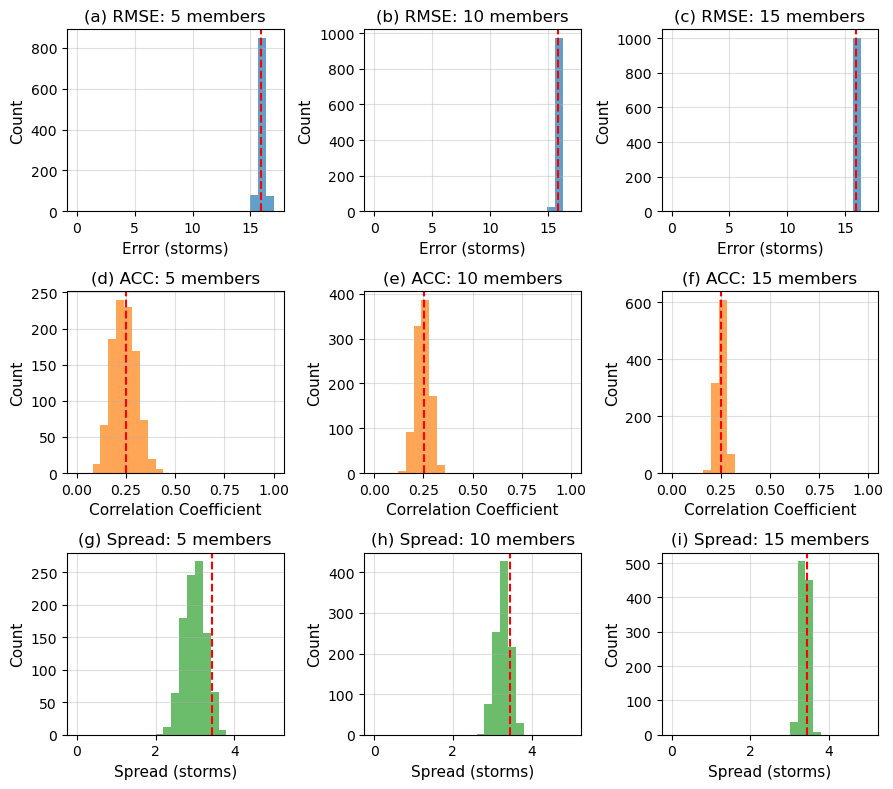

In [5]:
# Plot 
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(9, 8))
letters = "abcdefghi"
metrics = [
    (rmse_results, "tab:blue", "Error (storms)", (0, 17)),
    (acc_results, "tab:orange", "Correlation Coefficient", (0, 1)),
    (spread_results, "tab:green", "Spread (storms)", (0, 5)),
]
metric_names = ["RMSE", "ACC", "Spread"]

# Assuming member_counts = [5, 10, 20, 50] or similar — filter out 20
member_counts_plot = [n for n in member_counts if n != 20]

for row, (data_dict, color, xlabel, hist_range) in enumerate(metrics):
    for col, n in enumerate(member_counts_plot):
        ax = axes[row, col]
        data_dict[n].plot.hist(bins=25, alpha=0.7, color=color, ax=ax, range=hist_range)

        # Red vertical line for the 20-member value (median or mean)
        val_20 = data_dict[20].median()  # or .mean() depending on preference
        ax.axvline(val_20, color="red", linewidth=1.5, linestyle="--", label="20 members")

        ax.set_title(f"({letters[row*3+col]}) {metric_names[row]}: {n} members", fontsize=12)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
        ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("./figs/SI_figure_RMSE_ACC_spread_combined.png", bbox_inches="tight", dpi=600)
plt.show()